In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uttamkantidutta/amazon-processed/amazon_electronics_processed.csv


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("/kaggle/input/datasets/uttamkantidutta/amazon-processed/amazon_electronics_processed.csv")

df           

,Review_Text,Processed_Text,Sentiment,Product_ID,Product_Category,Rating,Review_Month,Helpful_Votes,Verified_Purchase
0,This is my 3td kindle and I love being able to...,3td kindle love able book,Positive,B07T6XMZQZ,Computers,4,2021-11,0,True
1,Build quality is fine and the Windows 11 came ...,build quality fine window 11 came running micr...,Negative,B0C7KBYGN4,Computers,2,2023-01,0,True
2,Would not connect to my computer even with tec...,not connect computer tech support help,Negative,B09G9STJF6,Computers,1,2023-02,0,True
3,"Like most lenses with bulbous front element, u...",like lens bulbous element using filter not ava...,Positive,B01738GIQG,Camera & Photo,5,2022-05,0,True
4,Work perfectly.,work perfectly,Positive,B000NK5Z8Y,Camera & Photo,5,2016-01,0,True
...,...,...,...,...,...,...,...,...,...
199642,"The sound was good, but I had to return them. ...",sound good return not stay ear hadnt exercised...,Negative,B00WSM6W8W,Home Audio & Theater,2,2014-07,0,True
199643,The laptop is great. Plays just about everyth...,laptop great play just steam account highest r...,Positive,B09J2BCP87,Computers,4,2022-04,1,True
199644,This amplifier is exactly what I was looking f...,amplifier exactly looking small simple powerfu...,Positive,B07Q41YB14,All Electronics,5,2021-01,0,True
199645,My high school son is impressed with everythin...,high school son impressed tool msword function...,Positive,B00FFVYSMK,Computers,5,2014-01,1,True


In [4]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    df["Processed_Text"],
    df["Sentiment"],
    test_size = 0.20,
    random_state = 42,
    stratify = df["Sentiment"]
)

print("Training:", len(X_train))
print("Testing :", len(X_test))

Training: 159717
Testing : 39930


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

y_train

array([2, 2, 0, ..., 1, 2, 0])

In [6]:
sentences_train = X_train.str.split().tolist()

print("Number of sentences:", len(sentences_train))
print("\nExample:")
print(sentences_train[0][:20])

Number of sentences: 159717

Example:
['good', 'cable', 'work']


In [7]:
#Train my own CBOW Word2Vec model

from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences = sentences_train,
    vector_size = 100,
    window = 5,
    min_count = 5,
    workers=4,
    sg=0,
    epochs=10,
    seed=42
)

In [8]:
print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 16724


In [9]:
print(w2v_model.wv.index_to_key[:30])

['not', 'great', 'work', 'good', 'use', 'just', 'like', 'product', 'no', 'sound', 'quality', 'time', 'easy', 'love', 'doe', 'case', 'price', 'camera', 'did', 'really', 'bought', 'cable', 'fit', 'im', 'battery', 'need', 'nice', 'tv', 'used', 'little']


In [10]:
vector = w2v_model.wv["battery"]

print(vector)
print("Vector shape:", vector.shape)

[-2.1039329   0.23539159  2.520235   -0.08868638  1.1691403   0.5838944
  1.5912589  -0.4282682  -0.02279653 -2.663273    0.73543465 -4.17872
  2.6625712   2.0543067  -0.4419641  -0.17822476  0.6018057   1.5589838
 -0.28339973 -2.7567046  -3.482174   -0.23925559 -2.9179206   3.2756743
 -0.66309816  1.0095432   0.02618144 -0.87215483 -0.15938434 -0.01557389
 -1.1841241   0.30002984 -0.5546918  -0.84997994 -0.9428032   2.4635034
 -0.05180986  2.5585601   1.101445   -4.2515445  -2.0396082  -1.6801298
 -4.2311487  -1.9198599  -0.69694674  3.5889513  -0.04455381  1.2007636
 -0.6030233   0.27410978  0.90141034  1.7830213   1.2949743  -1.8024434
  1.6917738   0.66601384 -0.7573068   1.3802844   0.0298061  -3.7107031
 -2.2938106  -0.23991098 -0.49632367 -2.1188045   1.87269     0.4129108
 -2.5498657   2.692162    1.041131   -0.5672868   2.1625473  -0.2601333
  0.62482953 -2.0804508  -0.10956436 -1.045284   -0.58455855 -0.32883367
 -0.15776496 -2.8403375  -1.8619885   2.7875693  -1.4110479  -1.

In [11]:
w2v_model.wv.most_similar("battery",topn = 10)

[('batter', 0.8229634165763855),
 ('expectancy', 0.6414204239845276),
 ('aa', 0.5915963053703308),
 ('aaa', 0.5885687470436096),
 ('span', 0.5873215198516846),
 ('recharge', 0.583904504776001),
 ('nimh', 0.5445743799209595),
 ('charge', 0.5433087348937988),
 ('9v', 0.5280197858810425),
 ('saver', 0.5241938829421997)]

In [12]:
w2v_model.wv.most_similar("sound", topn=10)

[('audio', 0.7129228115081787),
 ('bass', 0.7082967758178711),
 ('sounding', 0.7080627083778381),
 ('sounded', 0.6798653602600098),
 ('treble', 0.6060792803764343),
 ('loudness', 0.5972318053245544),
 ('anc', 0.5853934288024902),
 ('loud', 0.5830455422401428),
 ('vocal', 0.5799944400787354),
 ('speaker', 0.5776060819625854)]

In [13]:
w2v_model.wv.most_similar("charger", topn=10)

[('charging', 0.7232057452201843),
 ('charge', 0.7072351574897766),
 ('recharging', 0.5643506050109863),
 ('charged', 0.5514857769012451),
 ('recharge', 0.5507394671440125),
 ('cord', 0.5490158796310425),
 ('microusb', 0.5343188047409058),
 ('45w', 0.5169048309326172),
 ('outlet', 0.5157740712165833),
 ('typec', 0.5148208141326904)]

In [14]:
w2v_model.wv.similarity("battery", "charger")

np.float32(0.42591223)

In [15]:
w2v_model.wv.similarity("battery", "sound")

np.float32(0.07326451)

In [16]:
#visualize the 100-dimensional vectors

words = [
    "battery",
    "charger",
    "charging",
    "sound",
    "speaker",
    "quality",
    "cable",
    "screen",
    "camera",
    "laptop",
    "keyboard",
    "mouse",
    "product",
    "price",
    "device"
]

# Keep only words that exist in the Word2Vec vocabulary
words = [
    word for word in words
    if word in w2v_model.wv.key_to_index
]

print(words)

['battery', 'charger', 'charging', 'sound', 'speaker', 'quality', 'cable', 'screen', 'camera', 'laptop', 'keyboard', 'mouse', 'product', 'price', 'device']


In [17]:
import numpy as np

embedding_matrix = np.array([
    w2v_model.wv[word]
    for word in words
])

print("Shape:", embedding_matrix.shape)

Shape: (15, 100)


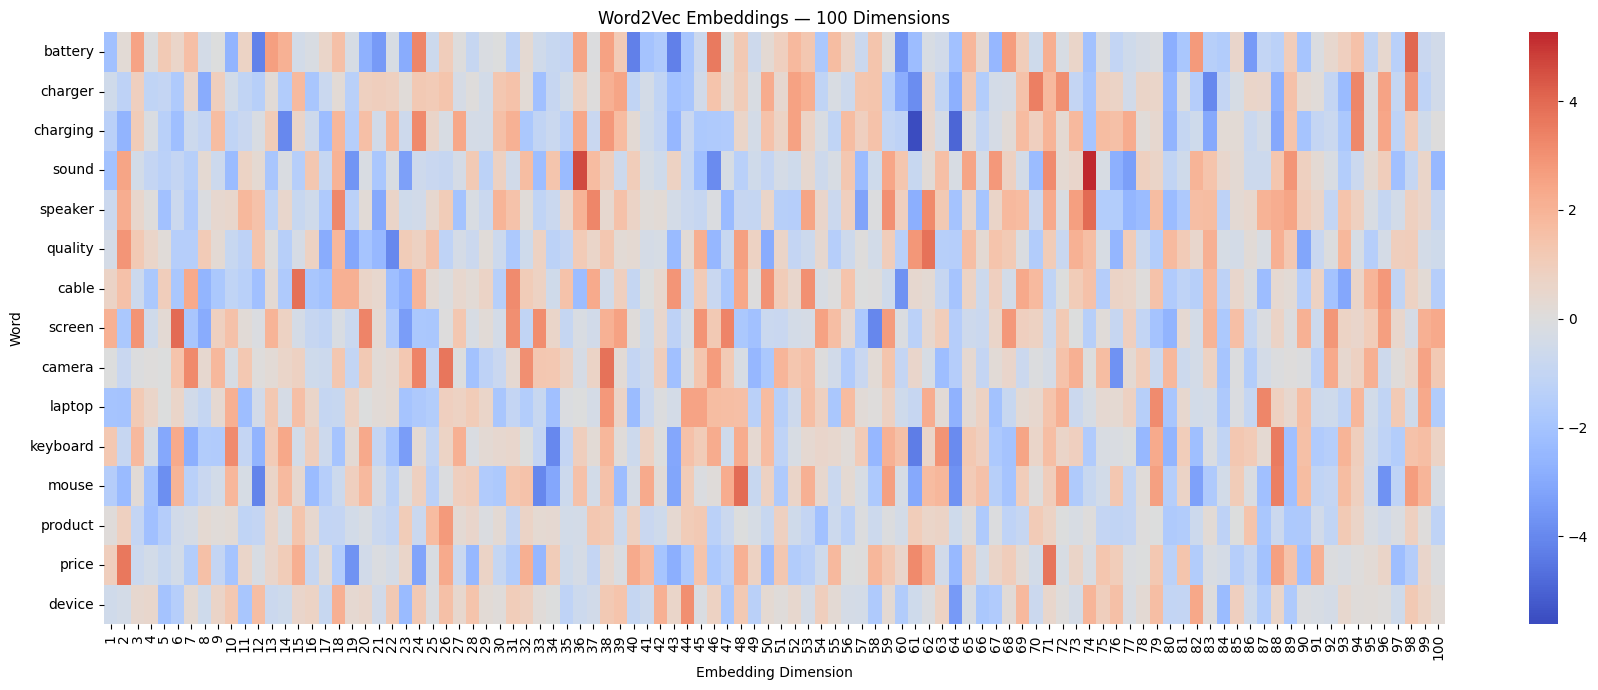

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 7))

sns.heatmap(
    embedding_matrix,
    xticklabels=range(1, 101),
    yticklabels=words,
    cmap="coolwarm",
    center=0
)

plt.title("Word2Vec Embeddings — 100 Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

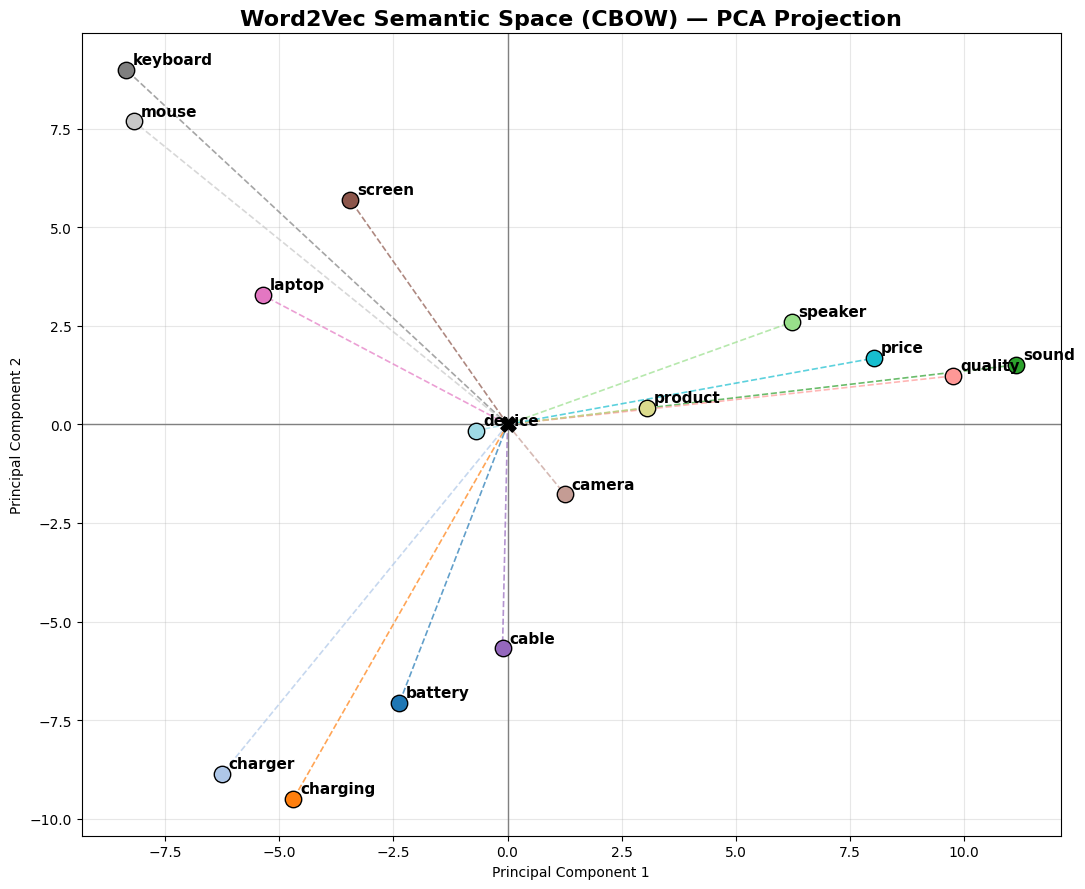

In [19]:
#PCA vusalization of the embeddings

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(embedding_matrix)

plt.figure(figsize=(11,9))

# Different colors
colors = plt.cm.tab20(np.linspace(0,1,len(words)))

# Origin
plt.scatter(0,0,color='black',s=120,marker='X',label='Origin',zorder=5)

for i, word in enumerate(words):

    # line from origin
    plt.plot(
        [0,vectors_2d[i,0]],
        [0,vectors_2d[i,1]],
        linestyle='--',
        linewidth=1.2,
        color=colors[i],
        alpha=0.7
    )

    # point
    plt.scatter(
        vectors_2d[i,0],
        vectors_2d[i,1],
        s=140,
        color=colors[i],
        edgecolor='black',
        zorder=3
    )

    # label
    plt.text(
        vectors_2d[i,0]+0.15,
        vectors_2d[i,1]+0.15,
        word,
        fontsize=11,
        weight='bold'
    )

plt.axhline(0,color='gray',linewidth=1)
plt.axvline(0,color='gray',linewidth=1)

plt.grid(alpha=0.3)
plt.title(
    "Word2Vec Semantic Space (CBOW) — PCA Projection",
    fontsize=16,
    weight='bold'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

In [20]:
# # ============================================================
# # Word2Vec Embedding Visualization — 3D PCA
# # ============================================================

# from sklearn.decomposition import PCA
# import numpy as np
# import plotly.graph_objects as go

# # ------------------------------------------------------------
# # 1. Reduce 100D Word2Vec vectors → 3D
# # ------------------------------------------------------------

# pca_3d = PCA(n_components=3)

# vectors_3d = pca_3d.fit_transform(embedding_matrix)

# explained_variance = pca_3d.explained_variance_ratio_

# print(f"PC1 explained variance: {explained_variance[0]:.2%}")
# print(f"PC2 explained variance: {explained_variance[1]:.2%}")
# print(f"PC3 explained variance: {explained_variance[2]:.2%}")
# print(f"Total explained variance: {explained_variance.sum():.2%}")


# # ------------------------------------------------------------
# # 2. Create colors
# # ------------------------------------------------------------

# colors = np.arange(len(words))


# # ------------------------------------------------------------
# # 3. Create figure
# # ------------------------------------------------------------

# fig = go.Figure()


# # ------------------------------------------------------------
# # 4. Add arrows from origin → each word
# # ------------------------------------------------------------

# for i, word in enumerate(words):

#     x = vectors_3d[i, 0]
#     y = vectors_3d[i, 1]
#     z = vectors_3d[i, 2]

#     # Line from origin to word
#     fig.add_trace(
#         go.Scatter3d(
#             x=[0, x],
#             y=[0, y],
#             z=[0, z],
#             mode="lines",
#             line=dict(
#                 width=4,
#                 color=f"hsl({i * 360 / len(words)}, 80%, 50%)"
#             ),
#             hoverinfo="skip",
#             showlegend=False
#         )
#     )


# # ------------------------------------------------------------
# # 5. Add word points
# # ------------------------------------------------------------

# fig.add_trace(
#     go.Scatter3d(
#         x=vectors_3d[:, 0],
#         y=vectors_3d[:, 1],
#         z=vectors_3d[:, 2],

#         mode="markers+text",

#         text=words,
#         textposition="top center",

#         marker=dict(
#             size=9,
#             color=colors,
#             colorscale="Turbo",
#             showscale=True,
#             colorbar=dict(
#                 title="Word Index"
#             ),
#             line=dict(
#                 width=1,
#                 color="black"
#             ),
#             opacity=0.95
#         ),

#         hovertemplate=(
#             "<b>%{text}</b><br>"
#             "PC1: %{x:.2f}<br>"
#             "PC2: %{y:.2f}<br>"
#             "PC3: %{z:.2f}"
#             "<extra></extra>"
#         ),

#         name="Words"
#     )
# )


# # ------------------------------------------------------------
# # 6. Add origin
# # ------------------------------------------------------------

# fig.add_trace(
#     go.Scatter3d(
#         x=[0],
#         y=[0],
#         z=[0],

#         mode="markers+text",

#         text=["Origin"],
#         textposition="bottom center",

#         marker=dict(
#             size=12,
#             color="black",
#             symbol="diamond"
#         ),

#         showlegend=False
#     )
# )


# # ------------------------------------------------------------
# # 7. Layout
# # ------------------------------------------------------------

# fig.update_layout(

#     title=dict(
#         text="Interactive 3D Word2Vec Semantic Space — CBOW",
#         x=0.5,
#         font=dict(
#             size=22
#         )
#     ),

#     scene=dict(

#         xaxis=dict(
#             title=f"PC1 ({explained_variance[0]:.1%} variance)",
#             backgroundcolor="white",
#             gridcolor="lightgray",
#             zeroline=True
#         ),

#         yaxis=dict(
#             title=f"PC2 ({explained_variance[1]:.1%} variance)",
#             backgroundcolor="white",
#             gridcolor="lightgray",
#             zeroline=True
#         ),

#         zaxis=dict(
#             title=f"PC3 ({explained_variance[2]:.1%} variance)",
#             backgroundcolor="white",
#             gridcolor="lightgray",
#             zeroline=True
#         ),

#         bgcolor="white"
#     ),

#     width=1100,
#     height=850,

#     margin=dict(
#         l=0,
#         r=0,
#         b=0,
#         t=70
#     )
# )

# import plotly.io as pio

# pio.renderers.default = "iframe"

# fig.show()

In [21]:
from collections import Counter

all_words = [word for sentence in sentences_train for word in sentence ]

word_counts = Counter(all_words)

In [22]:
top_100_words = [
    word 
    for word,count in word_counts.most_common(100)
    if word in w2v_model.wv.key_to_index
]

print("Number of words:", len(top_100_words))
print(top_100_words[:40])

Number of words: 100
['not', 'great', 'work', 'good', 'use', 'just', 'like', 'product', 'no', 'sound', 'quality', 'time', 'easy', 'love', 'doe', 'case', 'price', 'camera', 'did', 'really', 'bought', 'cable', 'fit', 'im', 'battery', 'need', 'nice', 'tv', 'used', 'little', 'using', 'phone', 'better', 'buy', 'device', 'thing', 'got', 'make', 'screen', 'problem']


In [23]:
embedding_matrix_100 = []

for i in top_100_words:
    embedding_matrix_100.append(w2v_model.wv[i])
embedding_matrix_100 = np.array(embedding_matrix_100)

print("Shape:", embedding_matrix_100.shape)
print(embedding_matrix_100)

Shape: (100, 100)
[[-1.1189394   0.3443823   1.0365424  ...  1.3963362  -0.3752011
  -1.2254212 ]
 [ 0.62757987 -1.0428293   1.2234664  ... -1.2192401  -0.562787
   0.6294161 ]
 [ 0.8380883  -2.28363     1.0657692  ...  0.43213445  1.759756
  -1.3009287 ]
 ...
 [ 0.6122945  -2.1455288   2.9395368  ...  0.9943661   1.3956352
   0.08920411]
 [ 1.7284057  -0.37349647 -0.73276603 ... -0.6274075  -0.51015335
   0.32066554]
 [-1.0399     -2.9021907  -1.1233431  ...  0.41161296  2.910885
   0.40535814]]


PC1 explained variance: 7.15%
PC2 explained variance: 5.67%
Total explained variance: 12.82%


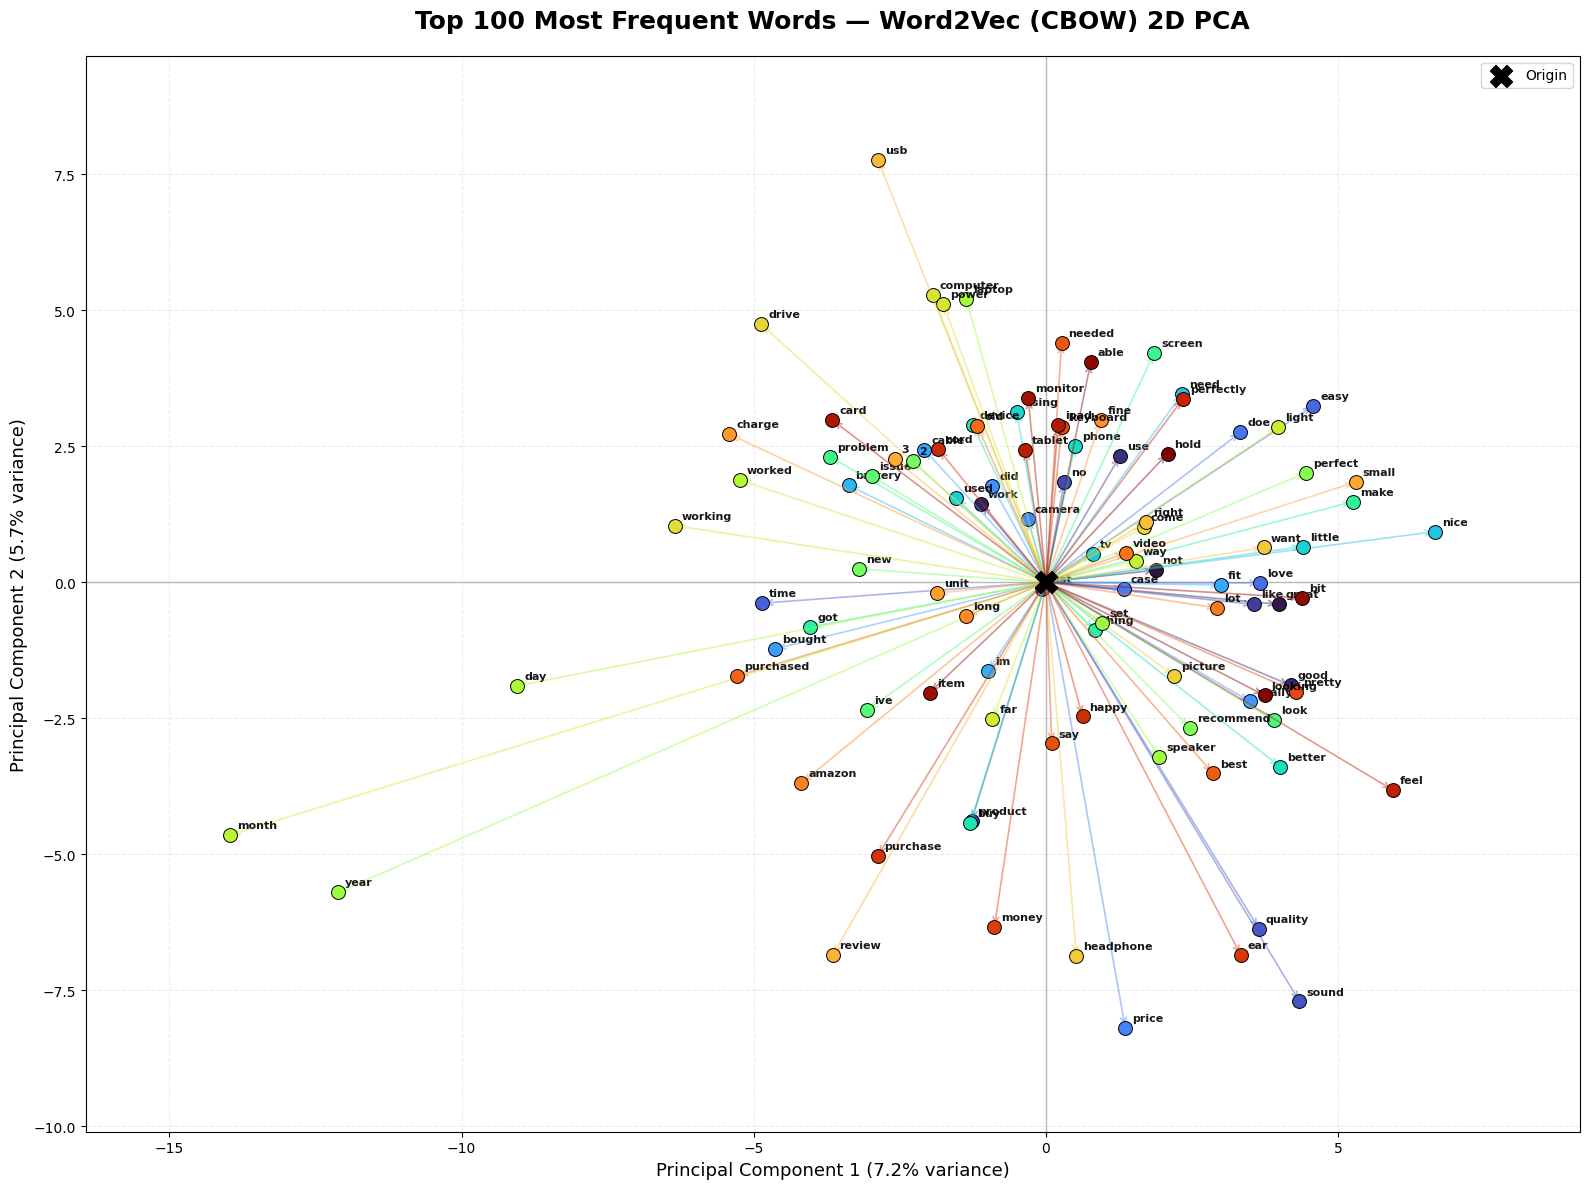

In [24]:
# ============================================================
# Word2Vec — Top 100 Words | 2D PCA Visualization
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. PCA: 100 dimensions → 2 dimensions
# ------------------------------------------------------------

pca_100 = PCA(n_components=2)

vectors_100_2d = pca_100.fit_transform(
    embedding_matrix_100
)

explained_variance = pca_100.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")


# ------------------------------------------------------------
# 2. Colors for the 100 words
# ------------------------------------------------------------

colors = plt.cm.turbo(
    np.linspace(0, 1, len(top_100_words))
)


# ------------------------------------------------------------
# 3. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 12))


# ------------------------------------------------------------
# 4. Plot arrows + points + labels
# ------------------------------------------------------------

for i, word in enumerate(top_100_words):

    x = vectors_100_2d[i, 0]
    y = vectors_100_2d[i, 1]

    # Arrow from origin to embedding position
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(0, 0),
        arrowprops=dict(
            arrowstyle="->",
            color=colors[i],
            linewidth=1.2,
            alpha=0.45
        )
    )

    # Word point
    ax.scatter(
        x,
        y,
        s=100,
        color=colors[i],
        edgecolor="black",
        linewidth=0.7,
        zorder=3
    )

    # Word label
    ax.annotate(
        word,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        alpha=0.9
    )


# ------------------------------------------------------------
# 5. Origin
# ------------------------------------------------------------

ax.scatter(
    0,
    0,
    s=250,
    color="black",
    marker="X",
    zorder=5,
    label="Origin"
)


# ------------------------------------------------------------
# 6. Axes
# ------------------------------------------------------------

ax.axhline(
    0,
    color="gray",
    linewidth=1,
    alpha=0.5
)

ax.axvline(
    0,
    color="gray",
    linewidth=1,
    alpha=0.5
)


# ------------------------------------------------------------
# 7. Formatting
# ------------------------------------------------------------

ax.set_title(
    "Top 100 Most Frequent Words — Word2Vec (CBOW) 2D PCA",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    f"Principal Component 1 "
    f"({explained_variance[0]:.1%} variance)",
    fontsize=13
)

ax.set_ylabel(
    f"Principal Component 2 "
    f"({explained_variance[1]:.1%} variance)",
    fontsize=13
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.25
)

ax.legend()

ax.margins(0.12)

plt.tight_layout()
plt.show()

In [25]:
w2v_model.wv.most_similar(["good"],topn = 10)

[('decent', 0.8252086043357849),
 ('great', 0.8027898669242859),
 ('excellent', 0.7000802159309387),
 ('impressive', 0.6549355387687683),
 ('nice', 0.6479107141494751),
 ('awesome', 0.6476855874061584),
 ('ok', 0.6244555115699768),
 ('bad', 0.6011838912963867),
 ('wise', 0.5991325378417969),
 ('best', 0.5898362994194031)]

In [26]:
w2v_model.wv.most_similar(["worst"],topn = 10)

[('best', 0.6756284832954407),
 ('terrible', 0.5567339658737183),
 ('horrible', 0.5314795970916748),
 ('worse', 0.5280377864837646),
 ('past', 0.5263543725013733),
 ('ive', 0.5164698362350464),
 ('garbage', 0.5163373351097107),
 ('awful', 0.47946444153785706),
 ('inferior', 0.457109659910202),
 ('junk', 0.4532705843448639)]

In [27]:
w2v_model.save("amazon_electronics_cbow_word2vec.model")

In [28]:
from gensim.models import Word2Vec

test_model = Word2Vec.load(
    "amazon_electronics_cbow_word2vec.model"
)

print("Vocabulary size:", len(test_model.wv))
print("Vector size:", test_model.wv.vector_size)

Vocabulary size: 16724
Vector size: 100


In [29]:
w2v_model.wv.save_word2vec_format(
    "amazon_electronics_cbow_vectors.txt",
    binary=False
)

#WORD_2_VEC is done here 

In [30]:
# Word2Vec vocabulary to Integer encoding here
word_to_index = {
    word: idx + 1
    for idx, word in enumerate(w2v_model.wv.index_to_key)
}

print("Vocabulary size:", len(word_to_index))

# Check a few words
for word in ["battery", "charger", "sound", "quality"]:
    if word in word_to_index:
        print(word, "→", word_to_index[word])

Vocabulary size: 16724
battery → 25
charger → 143
sound → 10
quality → 11


In [31]:
def text_to_sequence(text):
    return [
        word_to_index[word]
        for word in str(text).split()
        if word in word_to_index
    ]

X_train_seq = X_train.apply(text_to_sequence)
X_test_seq = X_test.apply(text_to_sequence)

print(X_train_seq.iloc[0])

[4, 22, 3]


In [32]:
import numpy as np

train_lengths = X_train_seq.apply(len)

print(train_lengths.describe())

print("\nPercentiles:")
print(
    train_lengths.quantile(
        [0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

count    159717.000000
mean         20.848019
std          34.422842
min           0.000000
25%           5.000000
50%          11.000000
75%          24.000000
max        1818.000000
Name: Processed_Text, dtype: float64

Percentiles:
0.900     47.000
0.950     71.000
0.990    157.000
0.995    208.000
0.999    367.284
Name: Processed_Text, dtype: float64


In [33]:
#padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 100

X_train_padded = pad_sequences(
    X_train_seq.tolist(),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_seq.tolist(),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_padded.shape)
print("Testing shape :", X_test_padded.shape)

Training shape: (159717, 100)
Testing shape : (39930, 100)


In [34]:
#Word2vec embedding matrix
import numpy as np

vocab_size = len(word_to_index) + 1
embedding_dim = w2v_model.wv.vector_size

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim),
    dtype=np.float32
)

for word, index in word_to_index.items():

    embedding_matrix[index] = w2v_model.wv[word]

print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)
print("Embedding matrix shape:", embedding_matrix.shape)

Vocabulary size: 16725
Embedding dimension: 100
Embedding matrix shape: (16725, 100)


In [35]:
word = "battery"

idx = word_to_index[word]

print("Word:", word)
print("Index:", idx)

print("\nWord2Vec vector:")
print(w2v_model.wv[word][:10])

print("\nEmbedding matrix vector:")
print(embedding_matrix[idx][:10])

Word: battery
Index: 25

Word2Vec vector:
[-2.1039329   0.23539159  2.520235   -0.08868638  1.1691403   0.5838944
  1.5912589  -0.4282682  -0.02279653 -2.663273  ]

Embedding matrix vector:
[-2.1039329   0.23539159  2.520235   -0.08868638  1.1691403   0.5838944
  1.5912589  -0.4282682  -0.02279653 -2.663273  ]


# ***NN Training parts starts from Here***

In [36]:
#Actuall Neural Network mannn 

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding , SimpleRNN,LSTM,GRU,Bidirectional, Dense, Dropout

# **SimpleRNN + Word2Vec(Frozen)**

In [37]:
#SimpleRNN + Word2Vec

from tensorflow.keras.layers import Input

NUM_CLASSES = 3 

#Simple RNN
rnn_model = Sequential([
    Input(shape=(MAX_LEN,)), 
    Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim,
        weights = [embedding_matrix],
        mask_zero=True, 
        trainable=False
    ),
    SimpleRNN(128, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

rnn_model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)
rnn_model.summary()

2026-08-19 14:49:59.598173: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,199 (6.49 MB)

 Trainable params: 29,699 (116.01 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [38]:
import tensorflow as tf

early_stopping_rnn = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [39]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate balanced class weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert the weights array into a dictionary format that Keras requires
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9213612905554152), 1: np.float64(5.111761881901105), 2: np.float64(0.43784592863076)}


In [40]:
history_rnn = rnn_model.fit(
    X_train_padded,
    y_train,
    
    validation_split=0.10,
    
    epochs=10,
    batch_size=128,
    
    class_weight=class_weights,
    
    callbacks=[early_stopping_rnn],
    
    verbose=1
)

Epoch 1/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 96s 83ms/step - accuracy: 0.6490 - loss: 0.9394 - val_accuracy: 0.6845 - val_loss: 0.7879
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 95s 85ms/step - accuracy: 0.6846 - loss: 0.8476 - val_accuracy: 0.7302 - val_loss: 0.6913
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 92s 82ms/step - accuracy: 0.6885 - loss: 0.8339 - val_accuracy: 0.6564 - val_loss: 0.8638
Epoch 4/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 92s 82ms/step - accuracy: 0.6770 - loss: 0.8515 - val_accuracy: 0.6416 - val_loss: 0.7843


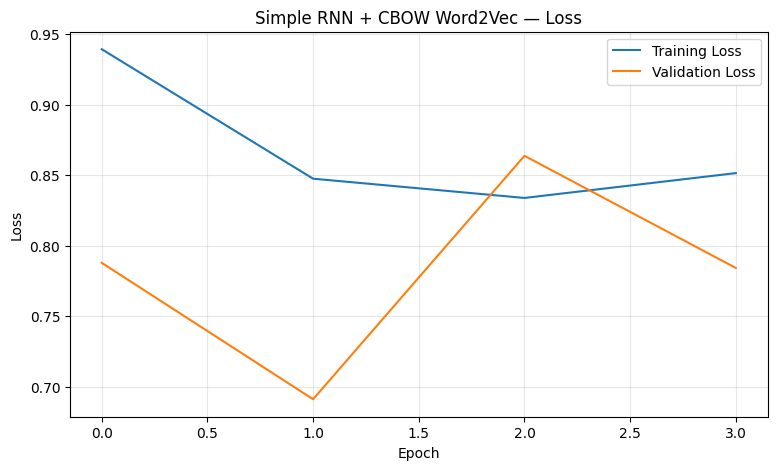

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_rnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_rnn.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simple RNN + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

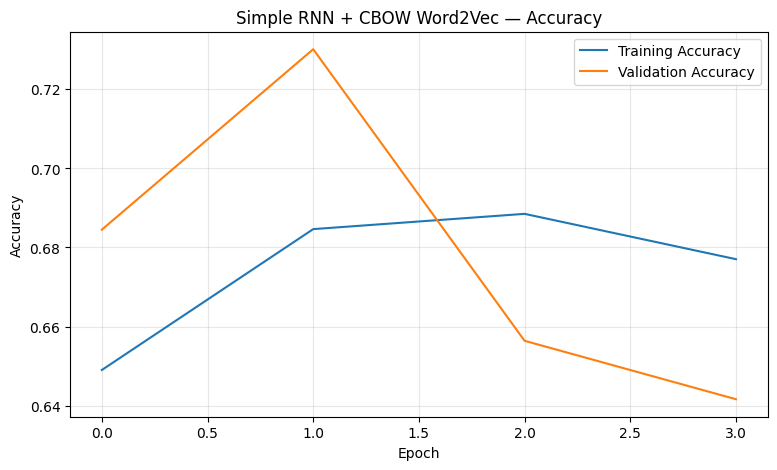

In [42]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_rnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_rnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Simple RNN + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **LSTM + Word2Vec**

In [43]:
#LSTM + Word2Vec

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

lstm_model = Sequential([
    
    Input(shape=(MAX_LEN,)),

    # Pre-trained CBOW Word2Vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False
    ),

    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,790,135 (6.83 MB)

 Trainable params: 117,635 (459.51 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [44]:
early_stopping_lstm = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_padded,
    y_train,

    validation_split=0.10,

    epochs=10,
    batch_size=128,

    class_weight=class_weights,

    callbacks=[early_stopping_lstm],

    verbose=1
)

Epoch 1/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 287s 252ms/step - accuracy: 0.7192 - loss: 0.7621 - val_accuracy: 0.7569 - val_loss: 0.5698
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 298s 265ms/step - accuracy: 0.7568 - loss: 0.6971 - val_accuracy: 0.7899 - val_loss: 0.5169
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 283s 252ms/step - accuracy: 0.7700 - loss: 0.6688 - val_accuracy: 0.7834 - val_loss: 0.5216
Epoch 4/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 283s 252ms/step - accuracy: 0.7773 - loss: 0.6511 - val_accuracy: 0.7804 - val_loss: 0.5287


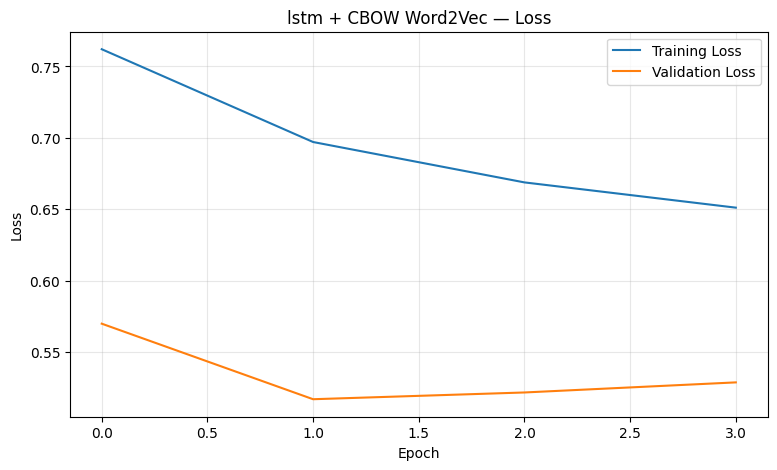

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("lstm + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

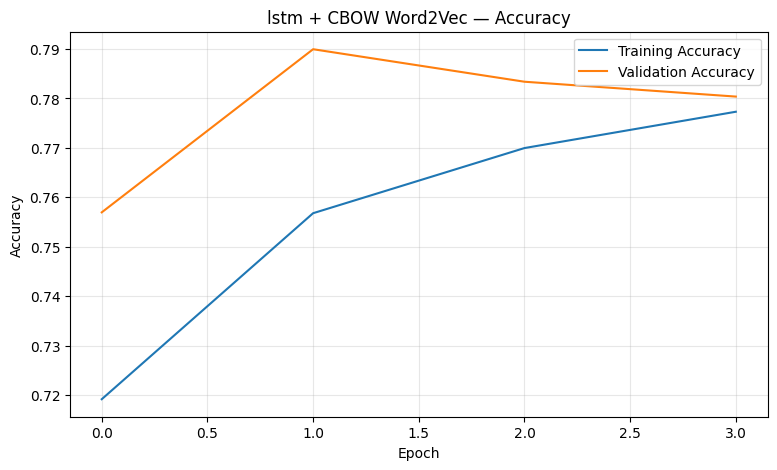

In [46]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_lstm.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_lstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("lstm + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **GRU + Word2Vec**

In [47]:
# ============================================================
# GRU + Word2Vec
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    GRU,
    Dropout,
    Dense
)

gru_model = Sequential([

    Input(shape=(MAX_LEN,)),

    # Pre-trained CBOW Word2Vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False
    ),

    GRU(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,761,207 (6.72 MB)

 Trainable params: 88,707 (346.51 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [48]:
early_stopping_gru = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_gru = gru_model.fit(
    X_train_padded,
    y_train,

    validation_split=0.10,

    epochs=10,
    batch_size=128,

    class_weight=class_weights,

    callbacks=[early_stopping_gru],

    verbose=1
)

Epoch 1/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 265s 232ms/step - accuracy: 0.7114 - loss: 0.7831 - val_accuracy: 0.7681 - val_loss: 0.5726
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 246s 219ms/step - accuracy: 0.7560 - loss: 0.6981 - val_accuracy: 0.7824 - val_loss: 0.5409
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 237s 211ms/step - accuracy: 0.7702 - loss: 0.6734 - val_accuracy: 0.8009 - val_loss: 0.5117
Epoch 4/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 239s 213ms/step - accuracy: 0.7781 - loss: 0.6573 - val_accuracy: 0.7943 - val_loss: 0.5136
Epoch 5/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 263s 234ms/step - accuracy: 0.7820 - loss: 0.6466 - val_accuracy: 0.7844 - val_loss: 0.5219


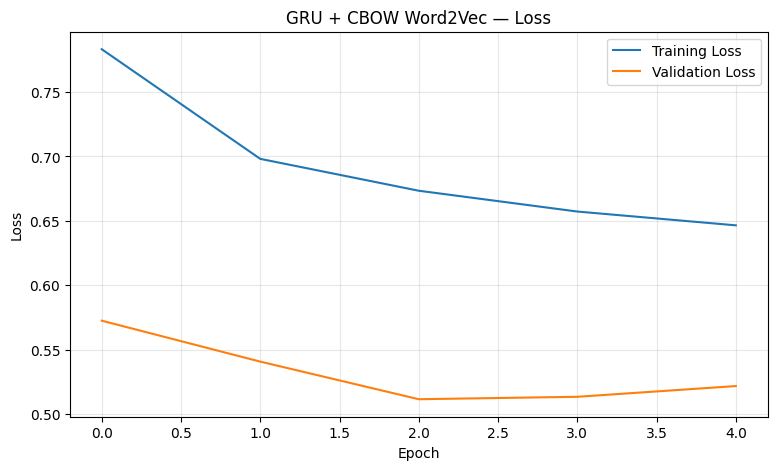

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_gru.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_gru.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

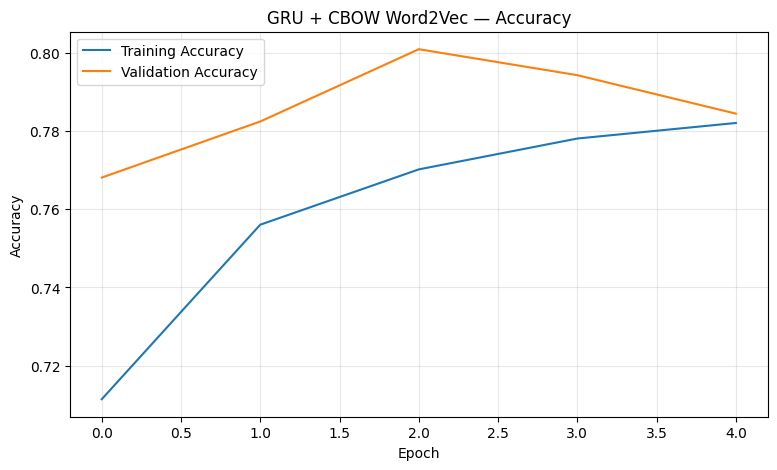

In [50]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_gru.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_gru.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **BiLSTM + Word2Vec**

In [51]:
# ============================================================
# BiLSTM + Word2Vec
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Bidirectional,
    Dropout,
    Dense
)

bilstm_model = Sequential([

    Input(shape=(MAX_LEN,)),

    # Pre-trained CBOW Word2Vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False
    ),

    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,907,767 (7.28 MB)

 Trainable params: 235,267 (919.01 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [52]:
early_stopping_bilstm = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_bilstm = bilstm_model.fit(
    X_train_padded,
    y_train,

    validation_split=0.10,

    epochs=10,
    batch_size=128,

    class_weight=class_weights,

    callbacks=[early_stopping_bilstm],

    verbose=1
)

Epoch 1/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 571s 500ms/step - accuracy: 0.7349 - loss: 0.7382 - val_accuracy: 0.7864 - val_loss: 0.5416
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 604s 537ms/step - accuracy: 0.7667 - loss: 0.6763 - val_accuracy: 0.7754 - val_loss: 0.5543
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 543s 483ms/step - accuracy: 0.7801 - loss: 0.6475 - val_accuracy: 0.7737 - val_loss: 0.5348
Epoch 4/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 556s 494ms/step - accuracy: 0.7867 - loss: 0.6290 - val_accuracy: 0.7823 - val_loss: 0.5284
Epoch 5/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 549s 489ms/step - accuracy: 0.7953 - loss: 0.6100 - val_accuracy: 0.7914 - val_loss: 0.5279
Epoch 6/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 573s 509ms/step - accuracy: 0.8020 - loss: 0.5950 - val_accuracy: 0.7909 - val_loss: 0.5169
Epoch 7/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 583s 518ms/step - accuracy: 0.8066 - loss: 0.5797 - val_accuracy: 0.7991 - val_loss: 0.5067
Epoch 8/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 570s 507ms/step - ac

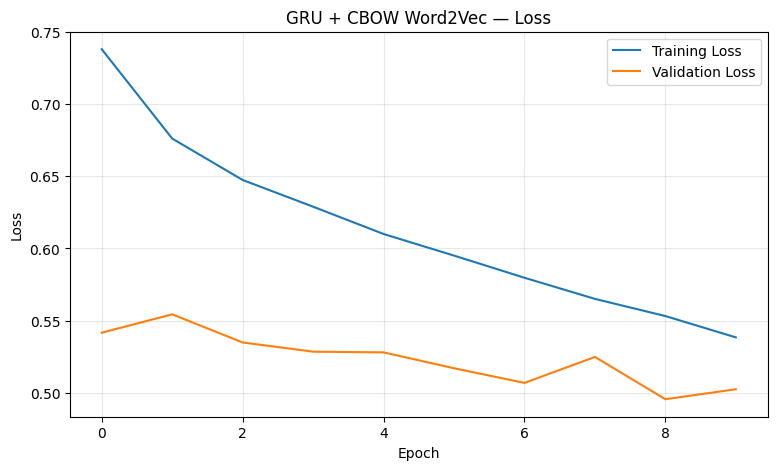

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_bilstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_bilstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

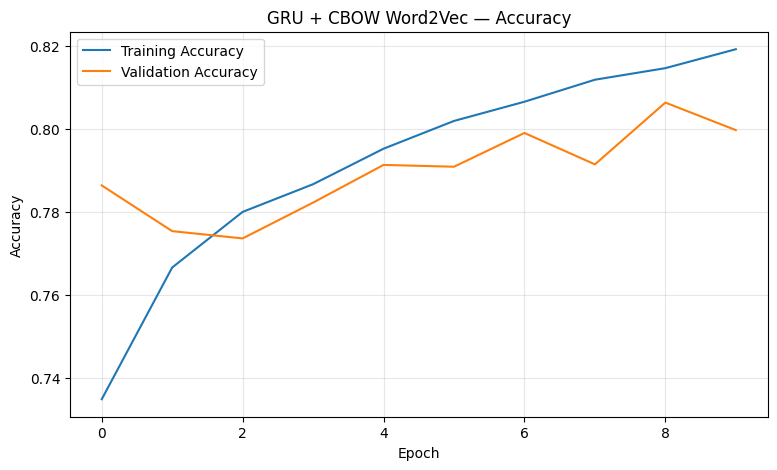

In [54]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_bilstm.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_bilstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()